<a href="https://colab.research.google.com/github/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/blob/main/LSTM_Pipeline_%C3%BAnica_s%C3%A9rie_temporal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================
# 1️⃣ Importar bibliotecas
# ==============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math


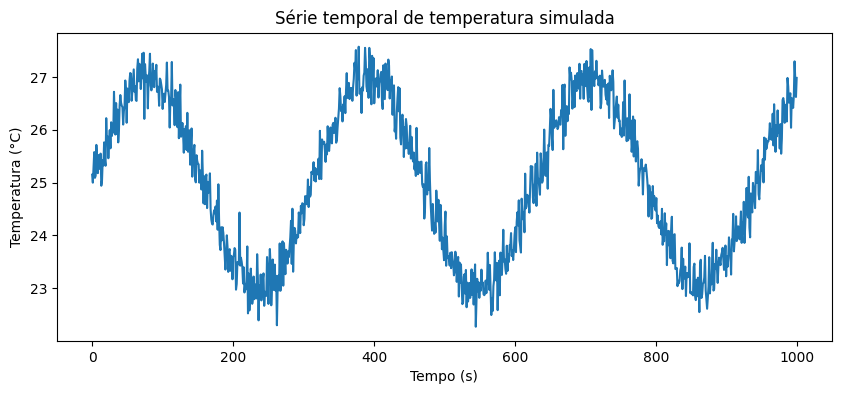

In [ ]:
# ==============================================
# 2️⃣ Gerar dados sintéticos (exemplo: temperatura)
# ==============================================
# Simulando 1000 segundos de temperatura variando suavemente com ruído
np.random.seed(42)
time = np.arange(0, 1000, 1)  # 1000 instantes (1 por segundo)
temp = 25 + 2*np.sin(time/50) + np.random.normal(0, 0.3, size=len(time))

plt.figure(figsize=(10,4))
plt.plot(time, temp)
plt.title("Série temporal de temperatura simulada")
plt.xlabel("Tempo (s)")
plt.ylabel("Temperatura (°C)")
plt.show()


In [ ]:
# ==============================================
# 3️⃣ Normalização dos dados
# ==============================================
# Escala entre 0 e 1 para estabilizar o treinamento da LSTM
scaler = MinMaxScaler(feature_range=(0,1))
temp_scaled = scaler.fit_transform(temp.reshape(-1,1))

print("Primeiros valores normalizados:")
print(temp_scaled[:5])


Primeiros valores normalizados:
[[0.54293436]
 [0.51453503]
 [0.56657357]
 [0.62366648]
 [0.53171948]]


In [ ]:
# ==============================================
# 4️⃣ Função para criar janelas temporais
# ==============================================
# window_size = quantos passos passados usar como entrada
# horizon = quantos passos à frente queremos prever
# A LSTM aprende relações entre observações consecutivas.
# Com window_size=10, ela observa os últimos 10 segundos para prever o próximo.
def create_sequences(data, window_size=10, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:(i+window_size), 0])
        y.append(data[i+window_size:i+window_size+horizon, 0])
    return np.array(X), np.array(y)

# Exemplo prático:
window_size = 10   # usa os últimos 10 segundos
horizon = 1        # prevê o próximo valor
X, y = create_sequences(temp_scaled, window_size, horizon)

print("Formato X:", X.shape, "| Formato y:", y.shape)


Formato X: (990, 10) | Formato y: (990, 1)


In [ ]:
# ==============================================
# 5️⃣ Split temporal de dados (treino/teste)
# ==============================================
# Importante: sem embaralhar (não é regressão comum)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# A LSTM espera entrada 3D: [amostras, passos de tempo, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [ ]:
# ==============================================
# 6️⃣ Construção do modelo LSTM
# ==============================================
# 64 neurônios → boa capacidade para captar padrões não lineares.
# Dropout → evita que memorize ruídos.
# return_sequences=False → queremos só a última saída (previsão do próximo ponto).
# Dense(horizon) → define o horizonte de previsão (pode ser 1, 3, 10 etc).

model = Sequential([
    LSTM(64, input_shape=(window_size, 1), return_sequences=False),
    Dropout(0.2),  # evita overfitting
    Dense(32, activation='relu'),
    Dense(horizon)  # saída com 1 passo à frente
])

optimizer = Adam(learning_rate=0.001)
model.compile(loss='mse', optimizer=optimizer)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1707 - val_loss: 0.0087
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0131 - val_loss: 0.0071
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0094 - val_loss: 0.0040
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0074 - val_loss: 0.0039
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0070 - val_loss: 0.0034
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - val_loss: 0.0034
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0056 - val_loss: 0.0039
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062 - val_loss: 0.0041
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0059 - val_loss: 0.0039
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0066 - val_loss: 0.0034
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0060 - val_loss: 0.0036
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

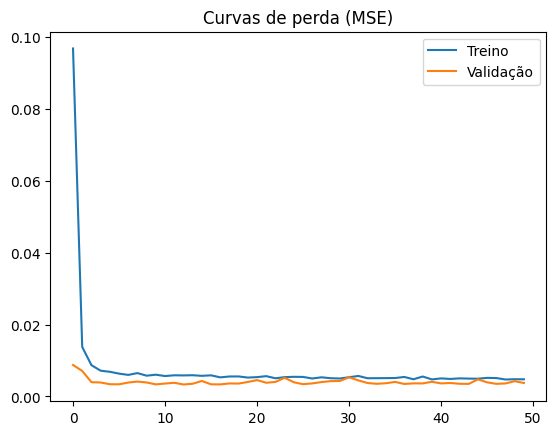

In [ ]:
# ==============================================
# 7️⃣ Treinamento do modelo
# ==============================================
#Em séries temporais, não se usa validação cruzada aleatória.
#Usa-se TimeSeriesSplit (do sklearn) ou rolling window,
# mas aqui usamos validation_split só para monitorar desempenho durante o treino.
history = model.fit(
    X_train, y_train,
    validation_split=0.1,   # separa 10% do treino para validar
    epochs=50,
    batch_size=32,
    verbose=1
)

plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.legend()
plt.title("Curvas de perda (MSE)")
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step
MAE: 0.259 | RMSE: 0.320


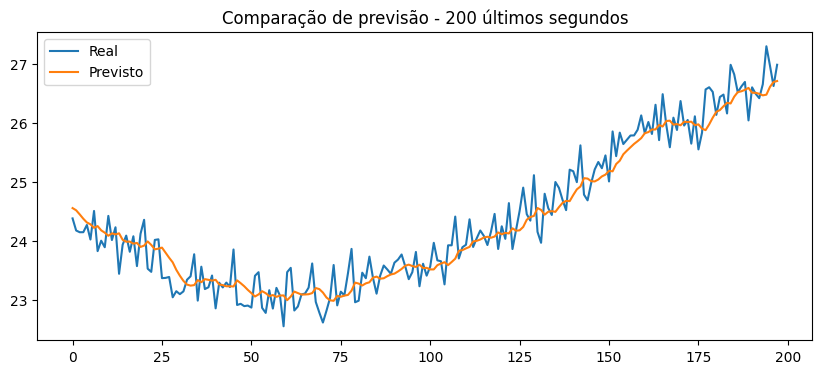

In [ ]:
# ==============================================
# 8️⃣ Avaliação no conjunto de teste
# ==============================================
y_pred = model.predict(X_test)

# Reverter normalização
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = math.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"MAE: {mae:.3f} | RMSE: {rmse:.3f}")

plt.figure(figsize=(10,4))
plt.plot(y_test_inv[:200], label='Real')
plt.plot(y_pred_inv[:200], label='Previsto')
plt.legend()
plt.title("Comparação de previsão - 200 últimos segundos")
plt.show()


In [ ]:
# ==============================================
# 9️⃣ Ajuste e hiperparametrização (explicação conceitual)
# ==============================================
# Aqui, poderíamos variar:
# - window_size: 5, 10, 20 (maior janela = mais contexto, mas mais difícil de treinar)
# - horizon: 1, 3, 5 (quantos segundos à frente prever)
# - n_neurons: 32, 64, 128 (capacidade da LSTM)
# - dropout_rate: 0.1 a 0.5 (controle de overfitting)
# - learning_rate: 0.0005, 0.001, 0.005 (impacta estabilidade)
# - epochs e batch_size
#
# Para automatizar:
# - usar Keras Tuner (RandomSearch ou BayesianOptimization)
# - definir função de criação do modelo e buscar melhor combinação.


In [ ]:
# ==============================================
# 🔟 Extensão: previsão de múltiplos passos à frente
# ==============================================
# Se quiser prever, por exemplo, os próximos 5 segundos:
window_size = 20
horizon = 5
X2, y2 = create_sequences(temp_scaled, window_size, horizon)
X2 = X2.reshape((X2.shape[0], X2.shape[1], 1))

model2 = Sequential([
    LSTM(64, input_shape=(window_size, 1), return_sequences=False),
    Dense(horizon)
])
model2.compile(loss='mse', optimizer=Adam(0.001))
model2.fit(X2[:800], y2[:800], epochs=20, batch_size=32, verbose=0)
pred2 = model2.predict(X2[800:])

print("Previsão de 5 passos à frente (exemplo):")
print(scaler.inverse_transform(pred2)[:1])
